# RNA Co-Generation dataset analysis

We use RNASolo2 from https://rnasolo.cs.put.poznan.pl/archive in a similar manner to RiboGen. 
Data is preprocessed by `data/process_data.py` into `data/processed.pt`.

This notebook works off `data/processed.pt` (one entry per unique sequence, all its structures) through the `Sequence` helper in `src/data/sec_utils.py`, so every cell below sees the same 4409 sequences / 11848 structures that the split is defined over.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys
sys.path.append('../')

from src.data.sec_utils import Sequence

In [2]:
train_idx, val_idx, test_idx = torch.load('../data/das_split.pt', weights_only=False)
sequences = Sequence.load_sequences_from_file('../data/processed.pt')

train_sequences = [sequences[i] for i in train_idx]
val_sequences = [sequences[i] for i in val_idx]
test_sequences = [sequences[i] for i in test_idx]

In [3]:
n_structs = np.array([s.n_structures for s in sequences])
print('Number of unique sequences:', len(sequences))
print('Total structures:', n_structs.sum())
print(f'Singletons: {(n_structs == 1).sum()}   most structures for one sequence: {n_structs.max()}')
print('Train/Validation/Test split:', len(train_sequences), len(val_sequences), len(test_sequences))

Number of unique sequences: 4409
Total structures: 11848
Singletons: 2867   most structures for one sequence: 289
Train/Validation/Test split: 4205 100 104


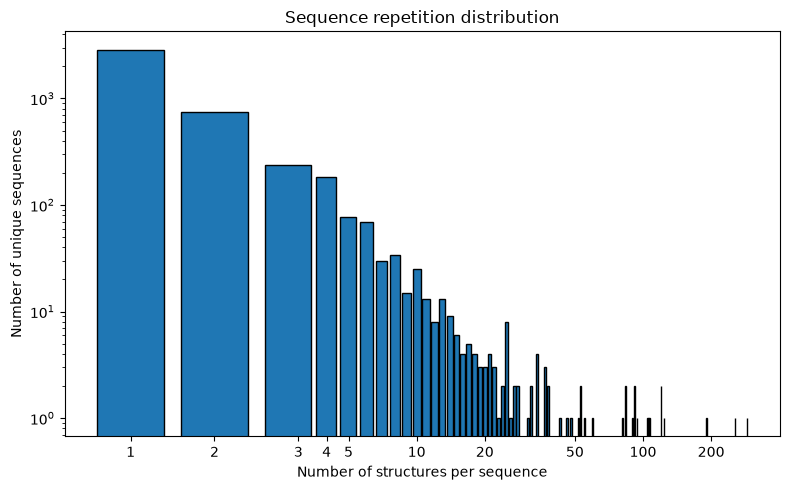

In [4]:
# How many structures does each unique sequence have?
repetition_counts, num_sequences_with_repetition = np.unique(n_structs, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(repetition_counts, num_sequences_with_repetition, width=0.8, edgecolor='black')
plt.xlabel('Number of structures per sequence')
plt.ylabel('Number of unique sequences')
plt.title('Sequence repetition distribution')
plt.xscale('symlog', linthresh=3)
plt.yscale('log')
plt.xticks(
    [1, 2, 3, 4, 5, 10, 20, 50, 100, 200],
    ['1', '2', '3', '4', '5', '10', '20', '50', '100', '200'],
)
plt.tight_layout()
plt.show()

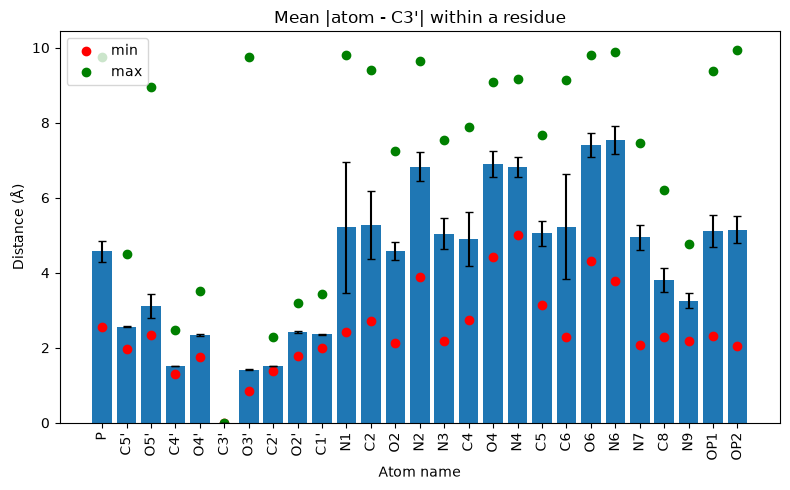

In [5]:
# Distance from each heavy atom to its residue's C3' frame origin, pooled over the corpus.
from src.constants import NUM_ATOM_SLOTS, ATOM_NAMES
from src.data.sec_utils import atom_offset_stats

pos_mean, pos_std, pos_min, pos_max, pos_count = atom_offset_stats(sequences)

plt.figure(figsize=(8, 5))
plt.bar(np.arange(NUM_ATOM_SLOTS), pos_mean)
plt.errorbar(
    np.arange(NUM_ATOM_SLOTS),
    pos_mean,
    yerr=pos_std,
    fmt='none',
    ecolor='black',
    capsize=3,
)
# add min and max as dots per atom
plt.scatter(np.arange(NUM_ATOM_SLOTS), pos_min, color='red', label='min')
plt.scatter(np.arange(NUM_ATOM_SLOTS), pos_max, color='green', label='max')
plt.xticks(np.arange(NUM_ATOM_SLOTS), ATOM_NAMES, rotation=90)
plt.xlabel('Atom name')
plt.ylabel('Distance (Å)')
plt.title("Mean |atom - C3'| within a residue")
plt.tight_layout()
plt.legend()
plt.show()

Same-sequence structure pairs: 195,657
RMSD  median 0.693 Å | mean 1.157 Å | max 44.32 Å
  below 0.5 Å:  27.4%
  below 1 Å:  68.0%
  below 2 Å:  81.7%
  below 3 Å:  90.4%
  below 5 Å:  99.1%


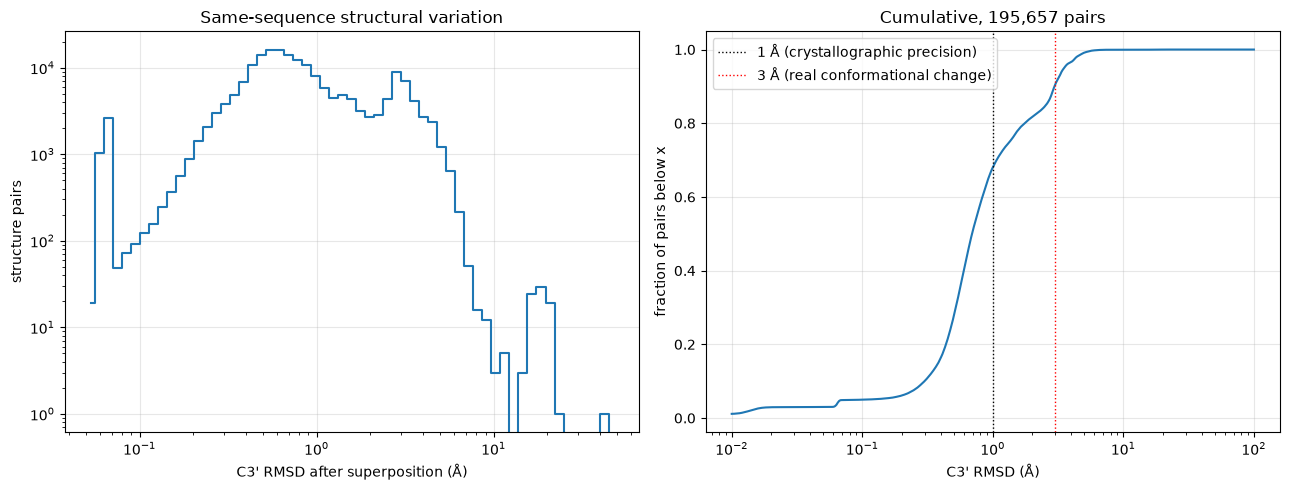

In [6]:
# Superposed C3' RMSD between all conformers of the same sequence.
pair_rmsd = []
for s in sequences:
    if s.n_structures < 2:
        continue
    M = s.pairwise_rmsd()                        # (C, C) on C3'
    iu = np.triu_indices(s.n_structures, k=1)    # off-diagonal only
    pair_rmsd.append(M[iu])
pair_rmsd = np.concatenate(pair_rmsd)

print(f'Same-sequence structure pairs: {len(pair_rmsd):,}')
print(f'RMSD  median {np.median(pair_rmsd):.3f} Å | mean {pair_rmsd.mean():.3f} Å | max {pair_rmsd.max():.2f} Å')
for cutoff in (0.5, 1, 2, 3, 5):
    print(f'  below {cutoff} Å: {100 * (pair_rmsd < cutoff).mean():5.1f}%')

bins = np.logspace(np.log10(0.05), np.log10(50), 60)
centres = np.sqrt(bins[:-1] * bins[1:])
counts, _ = np.histogram(pair_rmsd, bins=bins)

fig, (ax_hist, ax_line) = plt.subplots(1, 2, figsize=(13, 5))

ax_hist.step(centres, counts, where='mid')
ax_hist.set(xscale='log', yscale='log',
            xlabel="C3' RMSD after superposition (Å)", ylabel='structure pairs',
            title='Same-sequence structural variation')

grid = np.logspace(-2, 2, 400)
ax_line.plot(grid, [(pair_rmsd < x).mean() for x in grid])
ax_line.axvline(1.0, color='black', ls=':', lw=1, label='1 Å (crystallographic precision)')
ax_line.axvline(3.0, color='red', ls=':', lw=1, label='3 Å (real conformational change)')
ax_line.set(xscale='log', xlabel="C3' RMSD (Å)", ylabel='fraction of pairs below x',
            title=f'Cumulative, {len(pair_rmsd):,} pairs')
ax_line.legend()
for ax in (ax_hist, ax_line):
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Mean sequence length: 728.75
Standard deviation of sequence lengths: 1101.28
Sequences with more than one structure: 1542 / 4409
Total structures: 11848


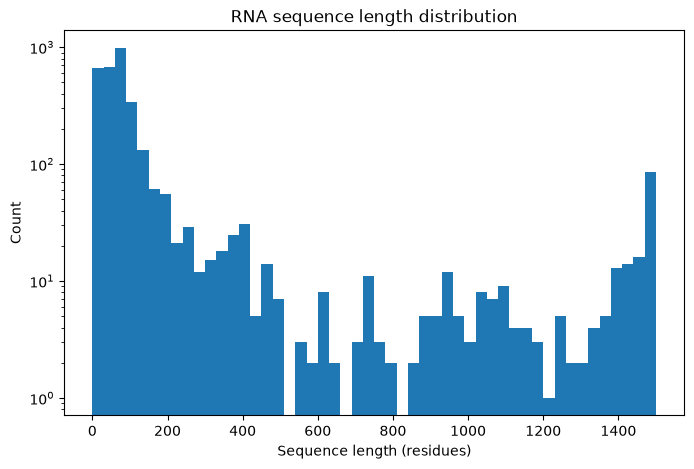

In [7]:
# Sequence lengths
seq_len = np.array([s.length for s in sequences])

print(f'Mean sequence length: {seq_len.mean():.2f}')
print(f'Standard deviation of sequence lengths: {seq_len.std():.2f}')

n_structs = np.array([s.n_structures for s in sequences])
print(f'Sequences with more than one structure: {(n_structs > 1).sum()} / {len(sequences)}')
print(f'Total structures: {n_structs.sum()}')

plt.figure(figsize=(8, 5))
plt.hist(seq_len, bins=50, range=(0, 1500))
plt.xlabel('Sequence length (residues)')
plt.ylabel('Count')
plt.yscale('log')
plt.title('RNA sequence length distribution')
plt.show()

{'A': 795284, 'C': 764139, 'G': 992217, 'U': 657259, '_': 4171}


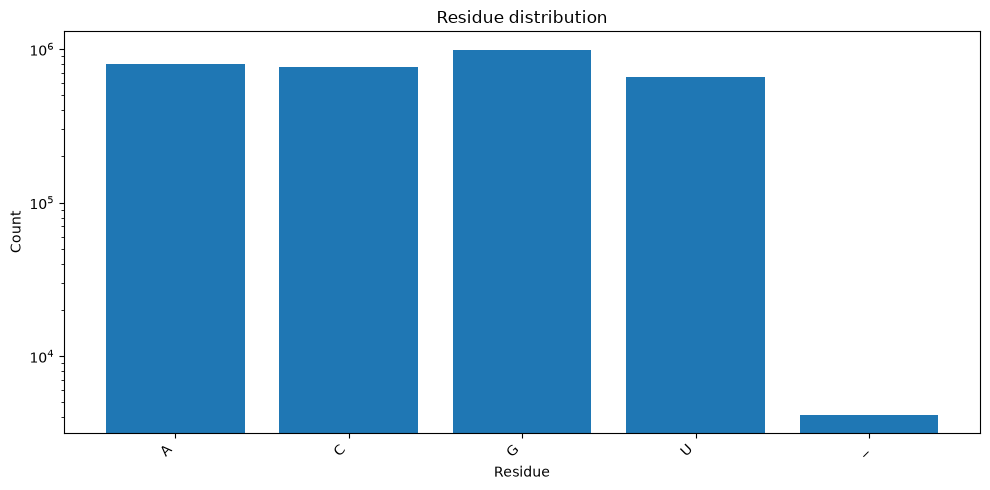

In [8]:
# Residue distribution, read off the sequence strings.
# NOTE: processed.pt stores sequences as the four canonical letters with every
# non-canonical / modified residue collapsed to '_', so individual modified
# nucleotides are not recoverable here -- the flat npz keeps `residue_names`.
labels = np.array([c for s in sequences for c in s.sequence])
unique_labels, label_counts = np.unique(labels, return_counts=True)

print(dict(zip(unique_labels.tolist(), label_counts.tolist())))

plt.figure(figsize=(10, 5))
plt.bar(unique_labels, label_counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Residue')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Residue distribution')
plt.tight_layout()
plt.show()

In [ ]:
# Position of the C3' frame origin across the corpus
from src.data.sec_utils import pooled_c3p

c3 = pooled_c3p(sequences)

print(f'Mean position: ({c3[:, 0].mean():.2f}, {c3[:, 1].mean():.2f}, {c3[:, 2].mean():.2f})')
print(f'Std  position: ({c3[:, 0].std():.2f}, {c3[:, 1].std():.2f}, {c3[:, 2].std():.2f})')

C3' count: 8,199,641
Mean position: (0.00, -0.00, 0.01)
Std  position: (38.64, 38.29, 37.68)


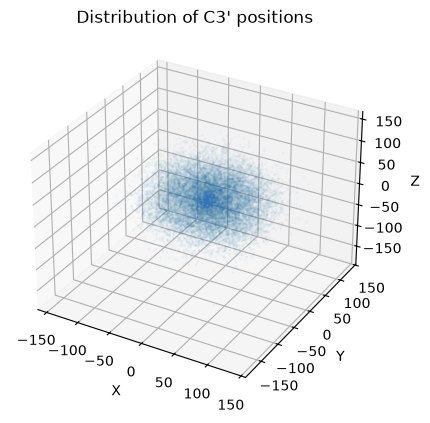

In [10]:
# Distribution of C3' positions in 3D (subsampled so the plot stays responsive)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
step = max(1, len(c3) // 20000)
ax.scatter(c3[::step, 0], c3[::step, 1], c3[::step, 2], alpha=0.2, s=1)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Distribution of C3' positions")
plt.show()

In [11]:
# Position of heavy atoms relative to their residue's C3'
from src.data.sec_utils import atom_position_stats

mean_xyz, std_xyz, n_atoms = atom_position_stats(sequences)

print(f'Heavy atoms: {n_atoms:,}')
print(f'Mean offset (Å): ({mean_xyz[0]:.3f}, {mean_xyz[1]:.3f}, {mean_xyz[2]:.3f})')
print(f'Std offset  (Å): ({std_xyz[0]:.3f}, {std_xyz[1]:.3f}, {std_xyz[2]:.3f})')

Heavy atoms: 175,696,579
Mean offset (Å): (-0.002, 0.002, -0.003)
Std offset  (Å): (2.442, 2.436, 2.431)


In [13]:
# C3' neighbour counts as a function of radius
radii = np.arange(0.1, 20.1, 1)

totals = {float(r): 0 for r in radii}
n_cells = 0
n_structs_total = 0
for s in sequences:
    counts = s.neighbor_counts(radii)
    for r in radii:
        totals[float(r)] += sum(counts[float(r)])
    n_cells += s.n_structures * s.length
    n_structs_total += s.n_structures

print(f'Mean number of nodes per structure: {n_cells / n_structs_total:.2f}')
for r in radii:
    print(f'Mean number of neighbors for max_radius={r:.1f}: {totals[float(r)] / n_cells:.2f}')

Mean number of nodes per structure: 692.07
Mean number of neighbors for max_radius=0.1: 0.00
Mean number of neighbors for max_radius=1.1: 0.00
Mean number of neighbors for max_radius=2.1: 0.00
Mean number of neighbors for max_radius=3.1: 0.00
Mean number of neighbors for max_radius=4.1: 0.00
Mean number of neighbors for max_radius=5.1: 0.08
Mean number of neighbors for max_radius=6.1: 1.74
Mean number of neighbors for max_radius=7.1: 2.41
Mean number of neighbors for max_radius=8.1: 2.75
Mean number of neighbors for max_radius=9.1: 3.25
Mean number of neighbors for max_radius=10.1: 4.03
Mean number of neighbors for max_radius=11.1: 5.81
Mean number of neighbors for max_radius=12.1: 8.42
Mean number of neighbors for max_radius=13.1: 10.63
Mean number of neighbors for max_radius=14.1: 13.19
Mean number of neighbors for max_radius=15.1: 16.02
Mean number of neighbors for max_radius=16.1: 19.81
Mean number of neighbors for max_radius=17.1: 23.51
Mean number of neighbors for max_radius=18.1